In [1]:
# Phase 2: Exploratory Data Analysis

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Global plot settings
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11

# Load cleaned dataset
from google.colab import drive
drive.mount('/content/drive')
file_path='/content/drive/MyDrive/HEALTHCARE /DATA/healthcare_dataset_cleaned.csv'
df = pd.read_csv(file_path, parse_dates=['Date of Admission', 'Discharge Date'])

#View basic infomation
print(f"Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(df.head(3))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset loaded: 54,860 rows × 16 columns
            Name  Age  Gender Blood Type Medical Condition Date of Admission  \
0  Bobby Jackson   30    Male         B-            Cancer        2024-01-31   
1   Leslie Terry   62    Male         A+           Obesity        2019-08-20   
2    Danny Smith   76  Female         A-           Obesity        2022-09-22   

             Doctor         Hospital Insurance Provider  Billing Amount  \
0     Matthew Smith  Sons and Miller         Blue Cross    18856.281306   
1   Samantha Davies          Kim Inc           Medicare    33643.327287   
2  Tiffany Mitchell         Cook PLC              Aetna    27955.096079   

   Room Number Admission Type Discharge Date   Medication  Test Results  \
0          328         Urgent     2024-02-02  Paracetamol        Normal   
1          265      Emergency     2019-08-26    Ibuprofen 

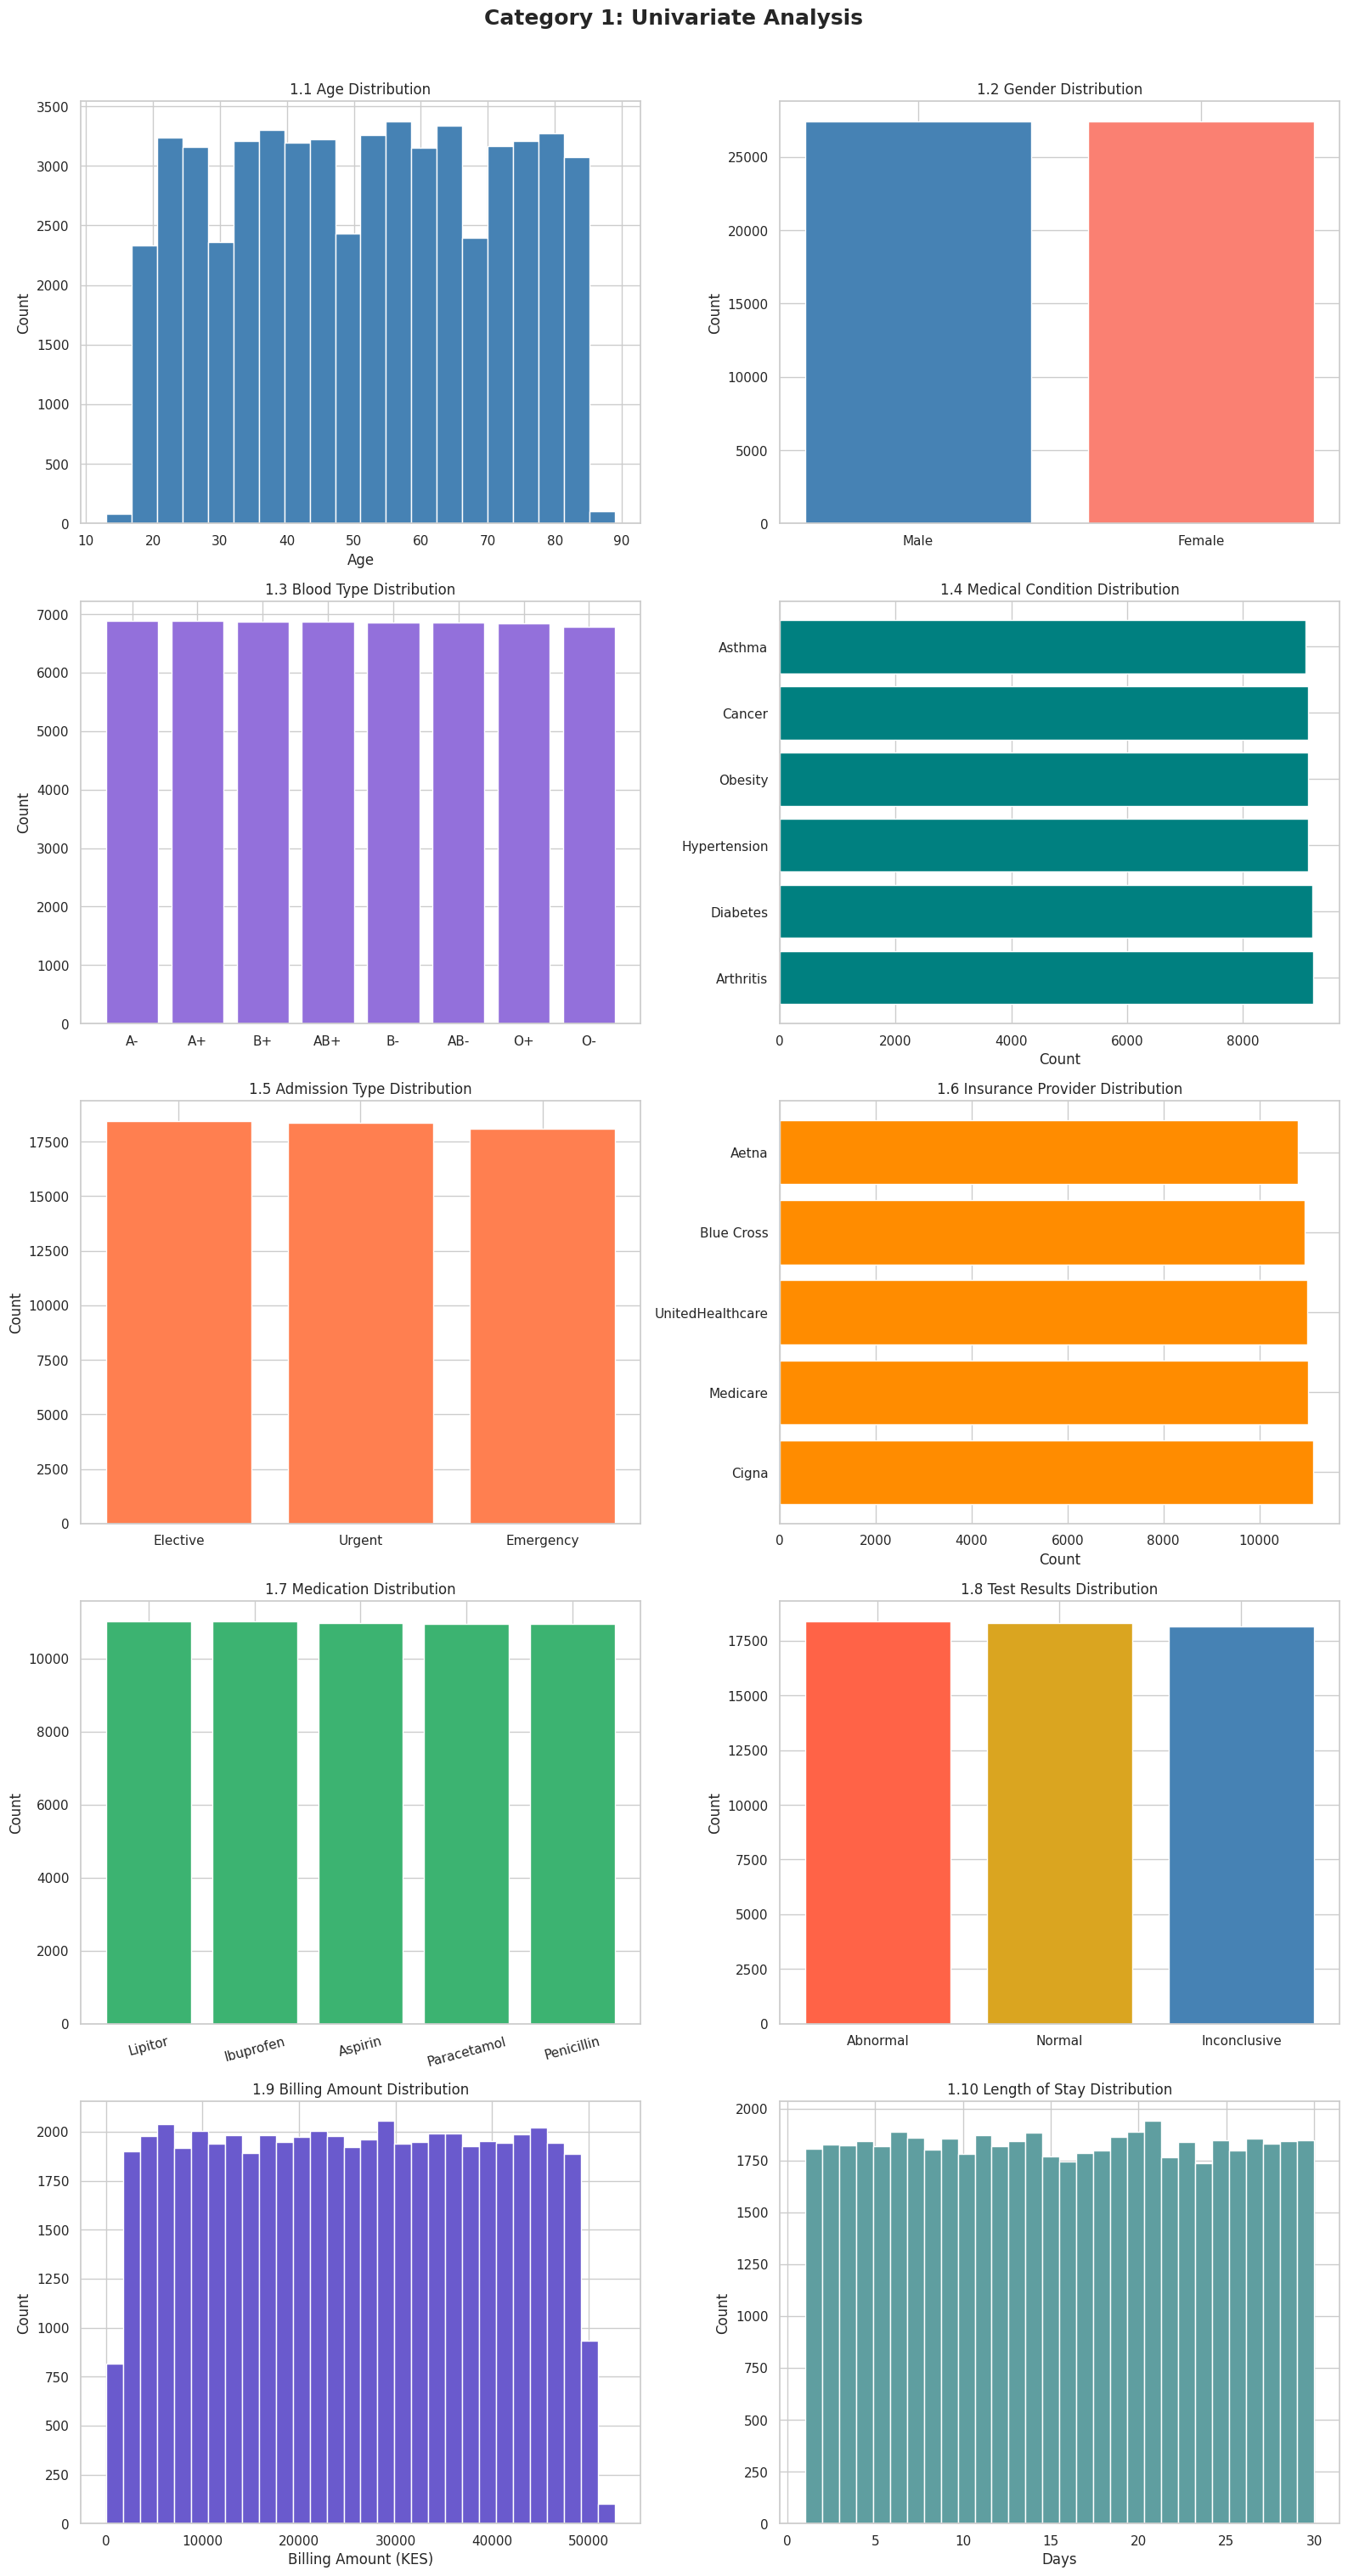

In [2]:
# ============================================================
# CATEGORY 1: UNIVARIATE ANALYSIS
# ============================================================

fig, axes = plt.subplots(5, 2, figsize=(16, 30))
fig.suptitle('Category 1: Univariate Analysis', fontsize=18, fontweight='bold', y=1.01)

# --- 1.1 Age Distribution ---
axes[0, 0].hist(df['Age'], bins=20, color='steelblue', edgecolor='white')
axes[0, 0].set_title('1.1 Age Distribution')
axes[0, 0].set_xlabel('Age')
axes[0, 0].set_ylabel('Count')

# --- 1.2 Gender Distribution ---
gender_counts = df['Gender'].value_counts()
axes[0, 1].bar(gender_counts.index, gender_counts.values, color=['steelblue', 'salmon'], edgecolor='white')
axes[0, 1].set_title('1.2 Gender Distribution')
axes[0, 1].set_ylabel('Count')

# --- 1.3 Blood Type Distribution ---
blood_counts = df['Blood Type'].value_counts()
axes[1, 0].bar(blood_counts.index, blood_counts.values, color='mediumpurple', edgecolor='white')
axes[1, 0].set_title('1.3 Blood Type Distribution')
axes[1, 0].set_ylabel('Count')

# --- 1.4 Medical Condition Distribution ---
cond_counts = df['Medical Condition'].value_counts()
axes[1, 1].barh(cond_counts.index, cond_counts.values, color='teal', edgecolor='white')
axes[1, 1].set_title('1.4 Medical Condition Distribution')
axes[1, 1].set_xlabel('Count')

# --- 1.5 Admission Type Distribution ---
adm_counts = df['Admission Type'].value_counts()
axes[2, 0].bar(adm_counts.index, adm_counts.values, color='coral', edgecolor='white')
axes[2, 0].set_title('1.5 Admission Type Distribution')
axes[2, 0].set_ylabel('Count')

# --- 1.6 Insurance Provider Distribution ---
ins_counts = df['Insurance Provider'].value_counts()
axes[2, 1].barh(ins_counts.index, ins_counts.values, color='darkorange', edgecolor='white')
axes[2, 1].set_title('1.6 Insurance Provider Distribution')
axes[2, 1].set_xlabel('Count')

# --- 1.7 Medication Distribution ---
med_counts = df['Medication'].value_counts()
axes[3, 0].bar(med_counts.index, med_counts.values, color='mediumseagreen', edgecolor='white')
axes[3, 0].set_title('1.7 Medication Distribution')
axes[3, 0].set_ylabel('Count')
axes[3, 0].tick_params(axis='x', rotation=15)

# --- 1.8 Test Results Distribution ---
test_counts = df['Test Results'].value_counts()
axes[3, 1].bar(test_counts.index, test_counts.values, color=['tomato', 'goldenrod', 'steelblue'], edgecolor='white')
axes[3, 1].set_title('1.8 Test Results Distribution')
axes[3, 1].set_ylabel('Count')

# --- 1.9 Billing Amount Distribution + Boxplot ---
axes[4, 0].hist(df['Billing Amount'], bins=30, color='slateblue', edgecolor='white')
axes[4, 0].set_title('1.9 Billing Amount Distribution')
axes[4, 0].set_xlabel('Billing Amount (KES)')
axes[4, 0].set_ylabel('Count')

# --- 1.10 Length of Stay Distribution ---
axes[4, 1].hist(df['Length of Stay'], bins=30, color='cadetblue', edgecolor='white')
axes[4, 1].set_title('1.10 Length of Stay Distribution')
axes[4, 1].set_xlabel('Days')
axes[4, 1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('eda_category1_univariate.png', dpi=150, bbox_inches='tight')
plt.show()



## Category 1 Findings — What the Data is Telling Us

**1.1 Age** — Nearly uniform distribution from age 20–80 with very few patients under 18 or over 85. No dominant age group — this dataset represents the general adult population evenly.

**1.2 Gender** — Almost perfectly balanced. Male ~27,800 vs Female ~27,700. No gender bias in the dataset.

**1.3 Blood Type** — Remarkably uniform across all 8 blood types (~6,900 each). This is unusual in real data — a signal that this is a synthetic dataset. Note this in your portfolio writeup.

**1.4 Medical Condition** — All 6 conditions (Arthritis, Cancer, Obesity, Hypertension, Diabetes, Asthma) are nearly equally distributed (~9,100–9,300 each). Again, synthetically balanced.

**1.5 Admission Type** — Elective, Urgent and Emergency are almost equal (~18,000 each). In real hospital data Emergency would dominate — another synthetic data signal.

**1.6 Insurance Provider** — Cigna leads slightly but all 5 providers are very close. No dominant insurer.

**1.7 Medication** — All 5 medications equally distributed (~11,000 each). Perfectly balanced — synthetic.

**1.8 Test Results** — Abnormal, Normal and Inconclusive nearly equal (~18,300–18,600). In real data Normal would dominate heavily.

**1.9 Billing Amount** — Roughly uniform between ~$1,000–$50,000 with slight dips at extremes. No heavy skew — unusual for real billing data which is typically right-skewed.

**1.10 Length of Stay** — Uniform distribution from 1–30 days. Real hospital data would be heavily right-skewed (most stays 1–5 days).

---

### Key Takeaway to Document
> This is a **synthetically generated dataset** — all variables are deliberately balanced. This means your EDA will focus more on **relationships between variables** rather than dominant patterns within individual variables.


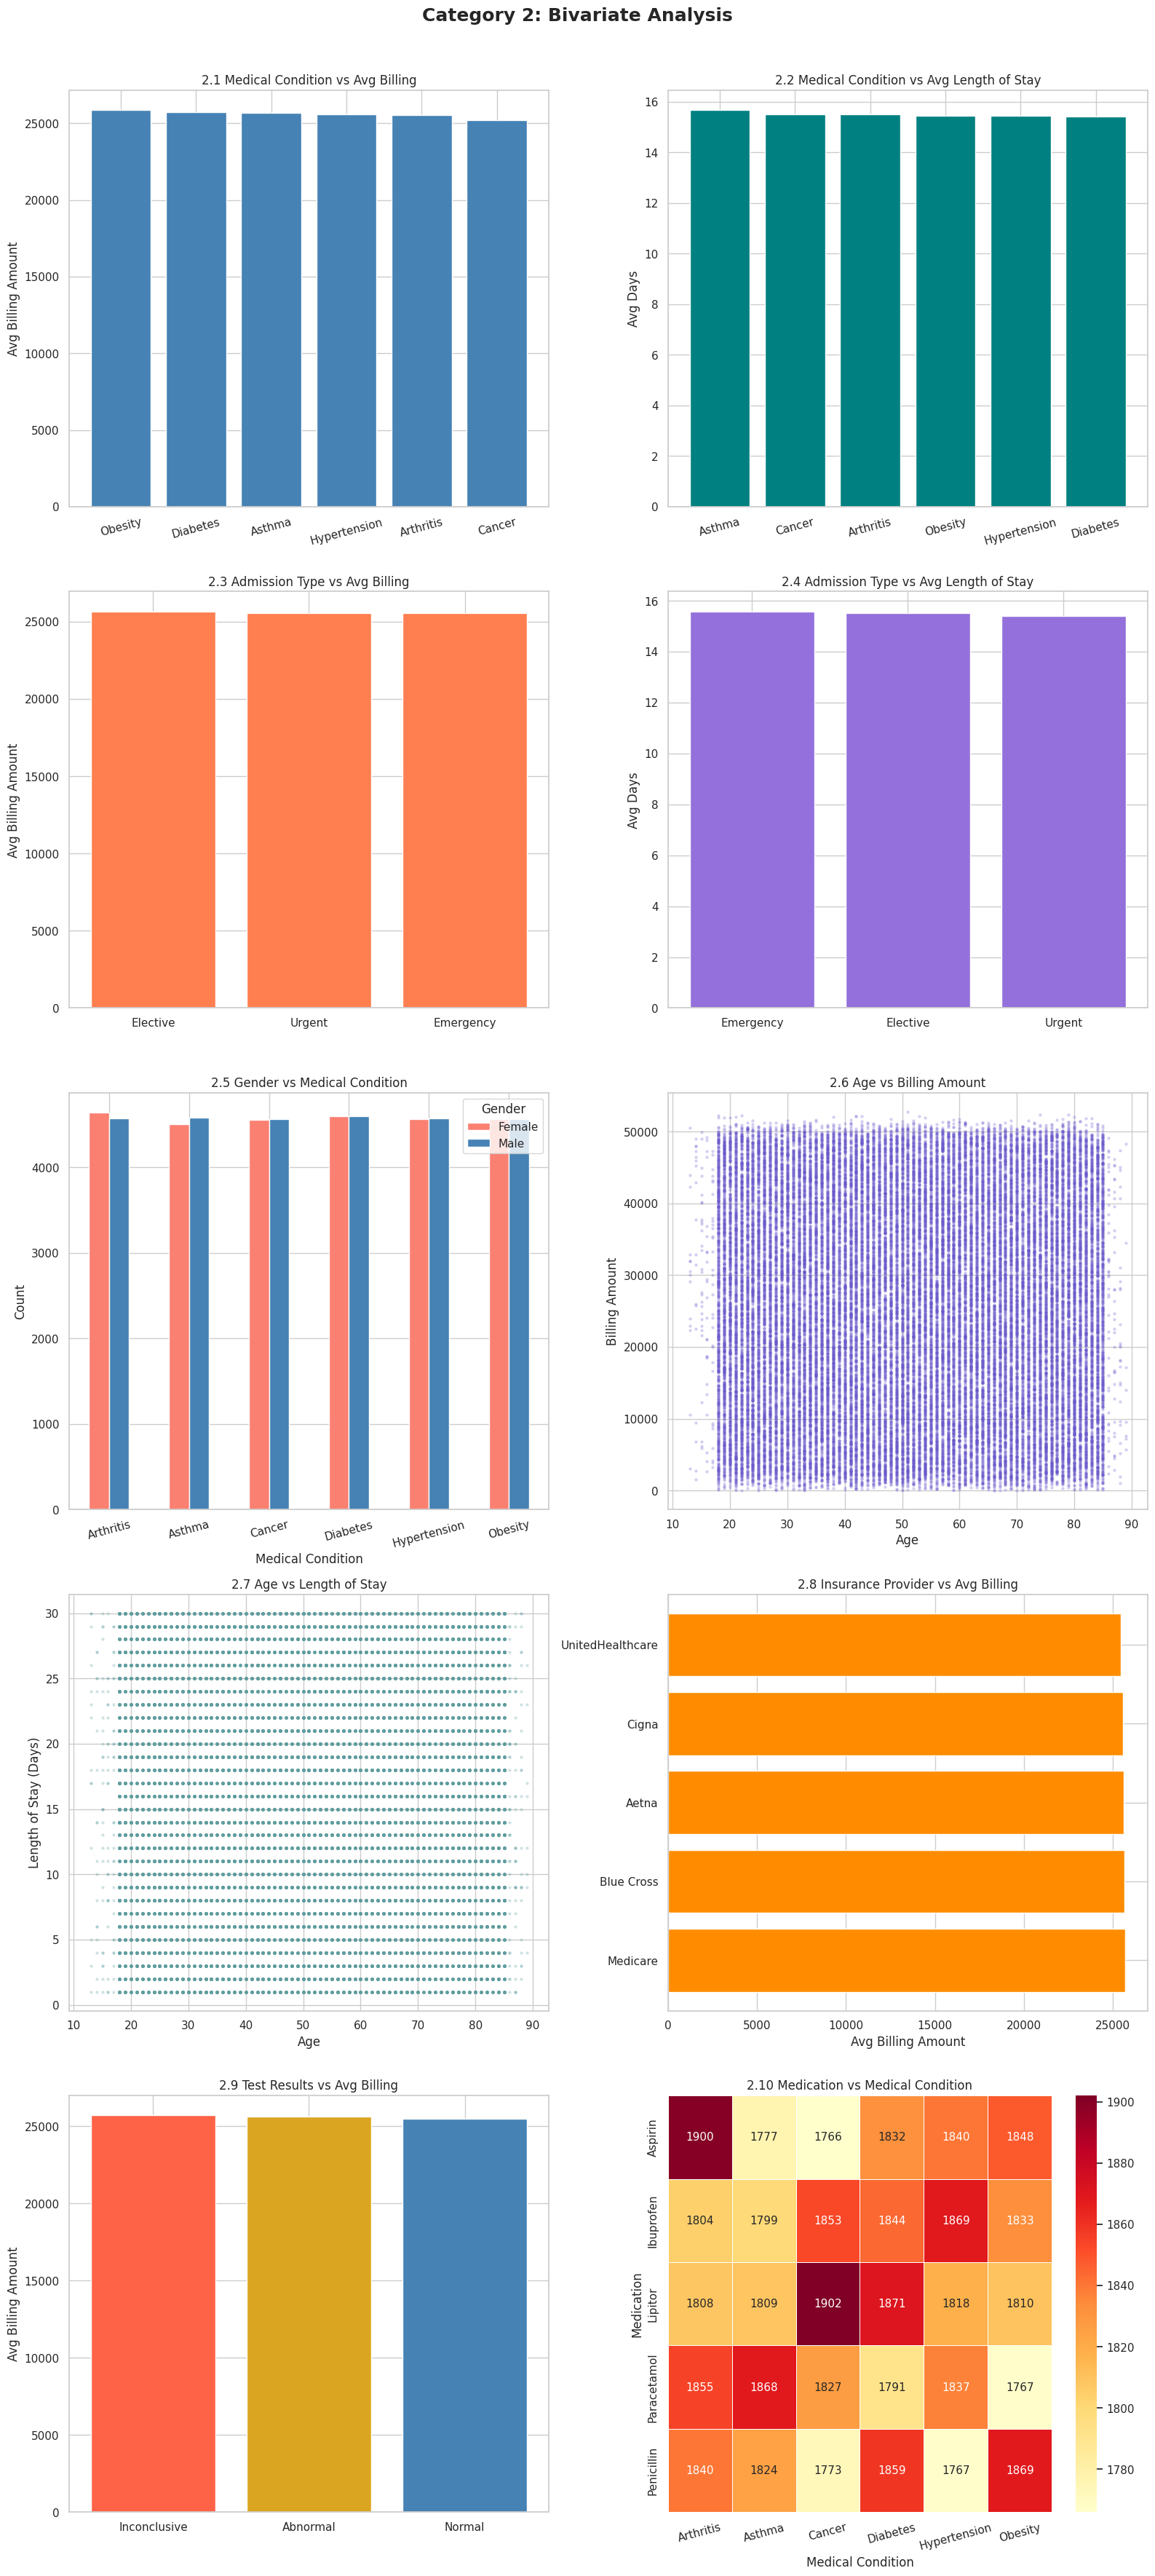

In [3]:
# ============================================================
# CATEGORY 2: BIVARIATE ANALYSIS
# ============================================================

fig, axes = plt.subplots(5, 2, figsize=(16, 35))
fig.suptitle('Category 2: Bivariate Analysis', fontsize=18, fontweight='bold', y=1.01)

# --- 2.1 Medical Condition vs Average Billing ---
cond_billing = df.groupby('Medical Condition')['Billing Amount'].mean().sort_values(ascending=False)
axes[0, 0].bar(cond_billing.index, cond_billing.values, color='steelblue', edgecolor='white')
axes[0, 0].set_title('2.1 Medical Condition vs Avg Billing')
axes[0, 0].set_ylabel('Avg Billing Amount')
axes[0, 0].tick_params(axis='x', rotation=15)

# --- 2.2 Medical Condition vs Average Length of Stay ---
cond_los = df.groupby('Medical Condition')['Length of Stay'].mean().sort_values(ascending=False)
axes[0, 1].bar(cond_los.index, cond_los.values, color='teal', edgecolor='white')
axes[0, 1].set_title('2.2 Medical Condition vs Avg Length of Stay')
axes[0, 1].set_ylabel('Avg Days')
axes[0, 1].tick_params(axis='x', rotation=15)

# --- 2.3 Admission Type vs Average Billing ---
adm_billing = df.groupby('Admission Type')['Billing Amount'].mean().sort_values(ascending=False)
axes[1, 0].bar(adm_billing.index, adm_billing.values, color='coral', edgecolor='white')
axes[1, 0].set_title('2.3 Admission Type vs Avg Billing')
axes[1, 0].set_ylabel('Avg Billing Amount')

# --- 2.4 Admission Type vs Average Length of Stay ---
adm_los = df.groupby('Admission Type')['Length of Stay'].mean().sort_values(ascending=False)
axes[1, 1].bar(adm_los.index, adm_los.values, color='mediumpurple', edgecolor='white')
axes[1, 1].set_title('2.4 Admission Type vs Avg Length of Stay')
axes[1, 1].set_ylabel('Avg Days')

# --- 2.5 Gender vs Medical Condition ---
gender_cond = df.groupby(['Medical Condition', 'Gender']).size().unstack()
gender_cond.plot(kind='bar', ax=axes[2, 0], color=['salmon', 'steelblue'], edgecolor='white')
axes[2, 0].set_title('2.5 Gender vs Medical Condition')
axes[2, 0].set_ylabel('Count')
axes[2, 0].tick_params(axis='x', rotation=15)
axes[2, 0].legend(title='Gender')

# --- 2.6 Age vs Billing Amount ---
axes[2, 1].scatter(df['Age'], df['Billing Amount'], alpha=0.2, color='slateblue', s=5)
axes[2, 1].set_title('2.6 Age vs Billing Amount')
axes[2, 1].set_xlabel('Age')
axes[2, 1].set_ylabel('Billing Amount')

# --- 2.7 Age vs Length of Stay ---
axes[3, 0].scatter(df['Age'], df['Length of Stay'], alpha=0.2, color='cadetblue', s=5)
axes[3, 0].set_title('2.7 Age vs Length of Stay')
axes[3, 0].set_xlabel('Age')
axes[3, 0].set_ylabel('Length of Stay (Days)')

# --- 2.8 Insurance Provider vs Average Billing ---
ins_billing = df.groupby('Insurance Provider')['Billing Amount'].mean().sort_values(ascending=False)
axes[3, 1].barh(ins_billing.index, ins_billing.values, color='darkorange', edgecolor='white')
axes[3, 1].set_title('2.8 Insurance Provider vs Avg Billing')
axes[3, 1].set_xlabel('Avg Billing Amount')

# --- 2.9 Test Results vs Average Billing ---
test_billing = df.groupby('Test Results')['Billing Amount'].mean().sort_values(ascending=False)
axes[4, 0].bar(test_billing.index, test_billing.values, color=['tomato', 'goldenrod', 'steelblue'], edgecolor='white')
axes[4, 0].set_title('2.9 Test Results vs Avg Billing')
axes[4, 0].set_ylabel('Avg Billing Amount')

# --- 2.10 Medication vs Medical Condition Heatmap ---
med_cond = df.groupby(['Medication', 'Medical Condition']).size().unstack()
sns.heatmap(med_cond, ax=axes[4, 1], cmap='YlOrRd', annot=True, fmt='d', linewidths=0.5)
axes[4, 1].set_title('2.10 Medication vs Medical Condition')
axes[4, 1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('eda_category2_bivariate.png', dpi=150, bbox_inches='tight')
plt.show()

## Category 2 Findings — Bivariate Analysis

**2.1 Medical Condition vs Avg Billing** — All 6 conditions bill almost identically (~$25,500). No condition is significantly more expensive than another — consistent with the synthetic nature of the dataset.

**2.2 Medical Condition vs Avg Length of Stay** — All conditions average ~15.5 days. No condition drives longer stays than another — again synthetically balanced.

**2.3 Admission Type vs Avg Billing** — Elective, Urgent and Emergency all average ~$25,500. In real data Emergency admissions would cost significantly more.

**2.4 Admission Type vs Avg Length of Stay** — All three admission types average ~15.5 days. In real data Emergency stays would be shorter and more intense.

**2.5 Gender vs Medical Condition** — Males and females are almost perfectly split across every condition (~4,600 each). No condition disproportionately affects one gender.

**2.6 Age vs Billing Amount** — Scatter plot shows a **completely random cloud** — no correlation between age and billing. Older patients do not cost more than younger ones in this dataset.

**2.7 Age vs Length of Stay** — Same story — perfectly random scatter. Age has no relationship with how long a patient stays.

**2.8 Insurance Provider vs Avg Billing** — UnitedHealthcare leads very slightly but all 5 providers are nearly identical at ~$25,500. No insurer is associated with higher bills.

**2.9 Test Results vs Avg Billing** — Inconclusive, Abnormal and Normal all bill ~$25,500. Test outcome has no impact on billing cost.

**2.10 Medication vs Medical Condition Heatmap** — Every medication is prescribed roughly equally across every condition (values range 1,766–1,902). No medication is condition-specific — unusual for real clinical data where medications are condition-targeted.

---

### Key Takeaway
> Bivariate analysis confirms this is a **fully randomized synthetic dataset** — no meaningful correlations exist between any two variables.



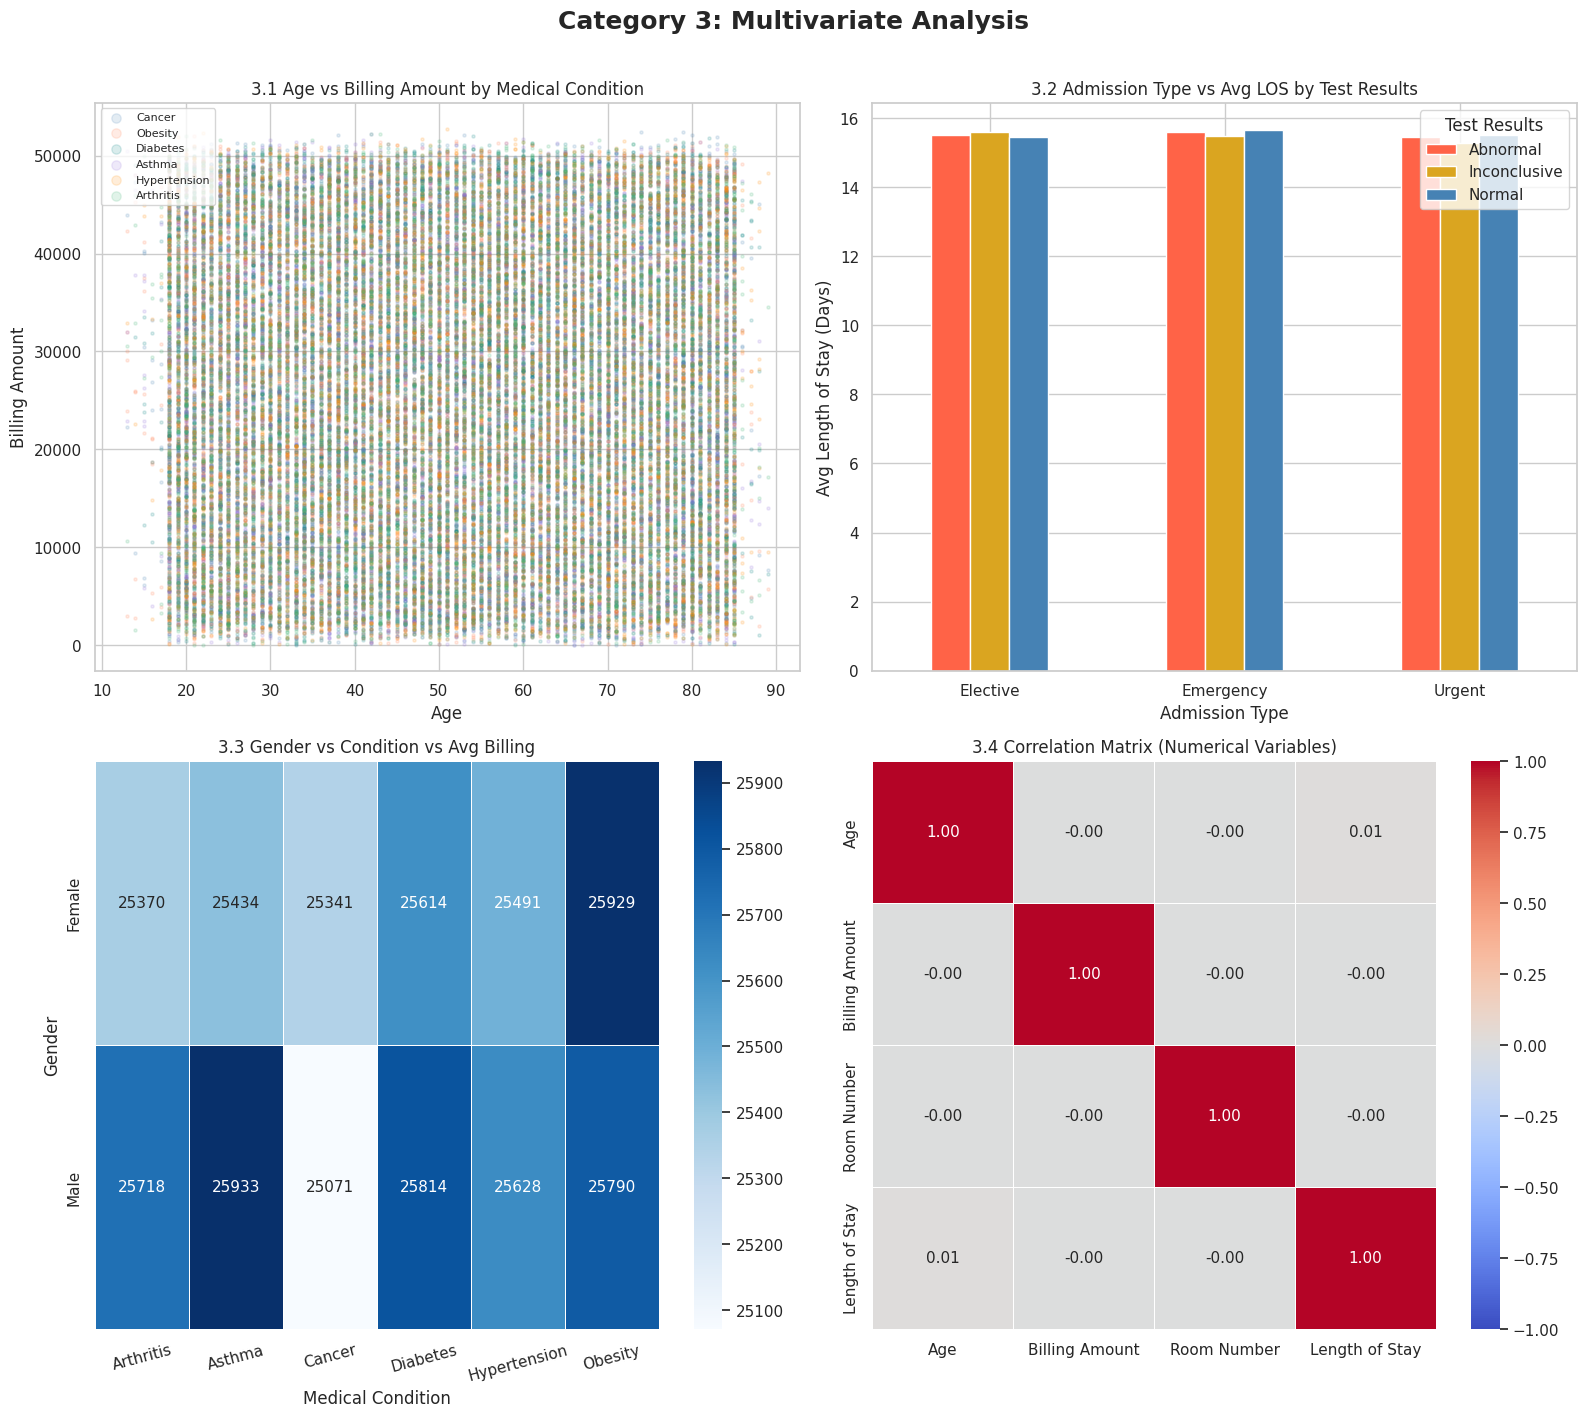

In [4]:
# ============================================================
# CATEGORY 3: MULTIVARIATE ANALYSIS
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
fig.suptitle('Category 3: Multivariate Analysis', fontsize=18, fontweight='bold', y=1.01)

# --- 3.1 Age vs Billing vs Medical Condition (color-coded scatter) ---
conditions = df['Medical Condition'].unique()
colors = ['steelblue', 'coral', 'teal', 'mediumpurple', 'darkorange', 'mediumseagreen']
for i, condition in enumerate(conditions):
    subset = df[df['Medical Condition'] == condition]
    axes[0, 0].scatter(subset['Age'], subset['Billing Amount'],
                       alpha=0.15, s=5, color=colors[i], label=condition)
axes[0, 0].set_title('3.1 Age vs Billing Amount by Medical Condition')
axes[0, 0].set_xlabel('Age')
axes[0, 0].set_ylabel('Billing Amount')
axes[0, 0].legend(markerscale=3, fontsize=8)

# --- 3.2 Admission Type vs Avg LOS vs Test Results ---
adm_los_test = df.groupby(['Admission Type', 'Test Results'])['Length of Stay'].mean().unstack()
adm_los_test.plot(kind='bar', ax=axes[0, 1], color=['tomato', 'goldenrod', 'steelblue'], edgecolor='white')
axes[0, 1].set_title('3.2 Admission Type vs Avg LOS by Test Results')
axes[0, 1].set_ylabel('Avg Length of Stay (Days)')
axes[0, 1].tick_params(axis='x', rotation=0)
axes[0, 1].legend(title='Test Results')

# --- 3.3 Gender vs Condition vs Average Billing Heatmap ---
gender_cond_billing = df.groupby(['Gender', 'Medical Condition'])['Billing Amount'].mean().unstack()
sns.heatmap(gender_cond_billing, ax=axes[1, 0], cmap='Blues', annot=True,
            fmt='.0f', linewidths=0.5)
axes[1, 0].set_title('3.3 Gender vs Condition vs Avg Billing')
axes[1, 0].tick_params(axis='x', rotation=15)

# --- 3.4 Correlation Matrix ---
num_cols = df[['Age', 'Billing Amount', 'Room Number', 'Length of Stay']]
corr = num_cols.corr()
sns.heatmap(corr, ax=axes[1, 1], cmap='coolwarm', annot=True,
            fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)
axes[1, 1].set_title('3.4 Correlation Matrix (Numerical Variables)')

plt.tight_layout()
plt.savefig('eda_category3_multivariate.png', dpi=150, bbox_inches='tight')
plt.show()

Category 3 Findings — Multivariate Analysis

3.1 Age vs Billing by Medical Condition — All 6 conditions form a perfectly overlapping random cloud across all ages and billing amounts. No condition clusters in any particular age or billing range — zero multivariate signal.

3.2 Admission Type vs Avg LOS by Test Results — All three test result outcomes (Abnormal, Inconclusive, Normal) produce identical average LOS (~15.5 days) across every admission type. Test results have no influence on how long a patient stays regardless of how they were admitted.

3.3 Gender vs Condition vs Avg Billing Heatmap — Billing ranges from $25,071 to $25,933 across all gender-condition combinations — a spread of only ~$862 across the entire matrix. Female Obesity patients bill the highest ($25,929), Male Cancer patients the lowest ($25,071) but the difference is negligible.

3.4 Correlation Matrix — This is the most important chart in Category 3. All correlations between Age, Billing Amount, Room Number and Length of Stay are effectively 0.00. No numerical variable is correlated with any other. This confirms definitively that the dataset was randomly generated.

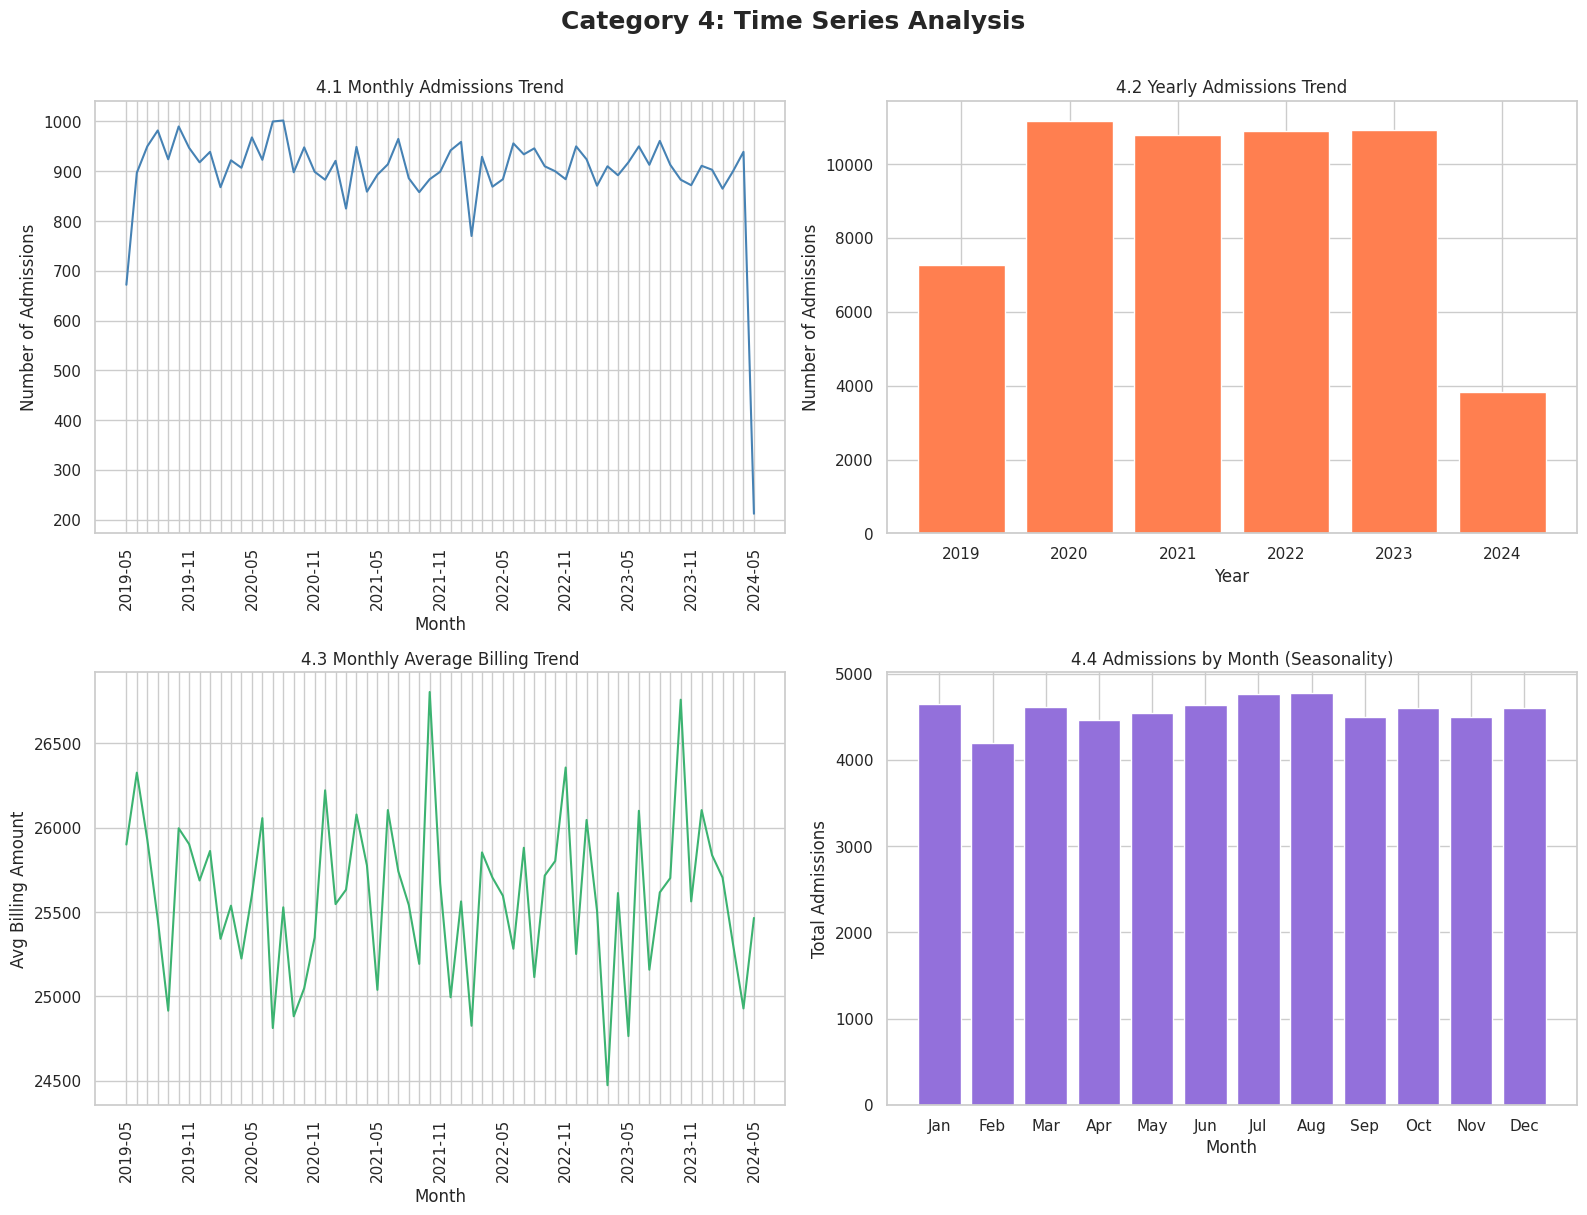

In [5]:
# ============================================================
# CATEGORY 4: TIME SERIES ANALYSIS
# ============================================================

# Extract time components
df['Admission Year'] = df['Date of Admission'].dt.year
df['Admission Month'] = df['Date of Admission'].dt.month
df['Admission Month Name'] = df['Date of Admission'].dt.strftime('%b')
df['Year-Month'] = df['Date of Admission'].dt.to_period('M')

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Category 4: Time Series Analysis', fontsize=18, fontweight='bold', y=1.01)

# --- 4.1 Monthly Admissions Trend ---
monthly = df.groupby('Year-Month').size()
axes[0, 0].plot(monthly.index.astype(str), monthly.values, color='steelblue', linewidth=1.5)
axes[0, 0].set_title('4.1 Monthly Admissions Trend')
axes[0, 0].set_xlabel('Month')
axes[0, 0].set_ylabel('Number of Admissions')
labels = [str(p) if i % 6 == 0 else '' for i, p in enumerate(monthly.index)]
axes[0, 0].set_xticks(range(len(monthly)))
axes[0, 0].set_xticklabels(labels, rotation=90)

# --- 4.2 Yearly Admissions Trend ---
yearly = df.groupby('Admission Year').size()
axes[0, 1].bar(yearly.index.astype(str), yearly.values, color='coral', edgecolor='white')
axes[0, 1].set_title('4.2 Yearly Admissions Trend')
axes[0, 1].set_xlabel('Year')
axes[0, 1].set_ylabel('Number of Admissions')

# --- 4.3 Monthly Average Billing Trend ---
monthly_billing = df.groupby('Year-Month')['Billing Amount'].mean()
axes[1, 0].plot(monthly_billing.index.astype(str), monthly_billing.values, color='mediumseagreen', linewidth=1.5)
axes[1, 0].set_title('4.3 Monthly Average Billing Trend')
axes[1, 0].set_xlabel('Month')
axes[1, 0].set_ylabel('Avg Billing Amount')
labels2 = [str(p) if i % 6 == 0 else '' for i, p in enumerate(monthly_billing.index)]
axes[1, 0].set_xticks(range(len(monthly_billing)))
axes[1, 0].set_xticklabels(labels2, rotation=90)

# --- 4.4 Admissions by Month Seasonality ---
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
seasonality = df.groupby('Admission Month Name').size().reindex(month_order)
axes[1, 1].bar(seasonality.index, seasonality.values, color='mediumpurple', edgecolor='white')
axes[1, 1].set_title('4.4 Admissions by Month (Seasonality)')
axes[1, 1].set_xlabel('Month')
axes[1, 1].set_ylabel('Total Admissions')

plt.tight_layout()
plt.savefig('eda_category4_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

Category 4 Findings — Time Series Analysis

4.1 Monthly Admissions Trend — Admissions stay consistently between 850–1,000 per month from mid-2019 through early 2024, then drop sharply at the end. The sharp drop at 2024-05 is not a real trend — it's because the dataset was generated up to a cutoff date mid-year, so the last few months have incomplete data. Note this in your writeup.

4.2 Yearly Admissions Trend — 2019 and 2024 show lower counts than 2020–2023 (~7,400 and ~3,800 respectively) — both are partial years in the dataset, not real dips. Years 2020–2023 each have a consistent ~10,500–11,000 admissions confirming uniform generation across full years.

4.3 Monthly Average Billing Trend — Billing fluctuates randomly between ~$24,500–$27,000 monthly with no upward or downward trend over 5 years. In real hospital data you would expect billing to increase year-on-year due to inflation and rising healthcare costs. The flat trend is another synthetic data signature.

4.4 Seasonality — Admissions are almost perfectly flat across all 12 months (~4,300–4,800). February is slightly lower — expected since it has fewer days. No seasonal spikes in any month. Real hospital data typically shows spikes in flu season (June–August in Kenya) and dips in holiday months.

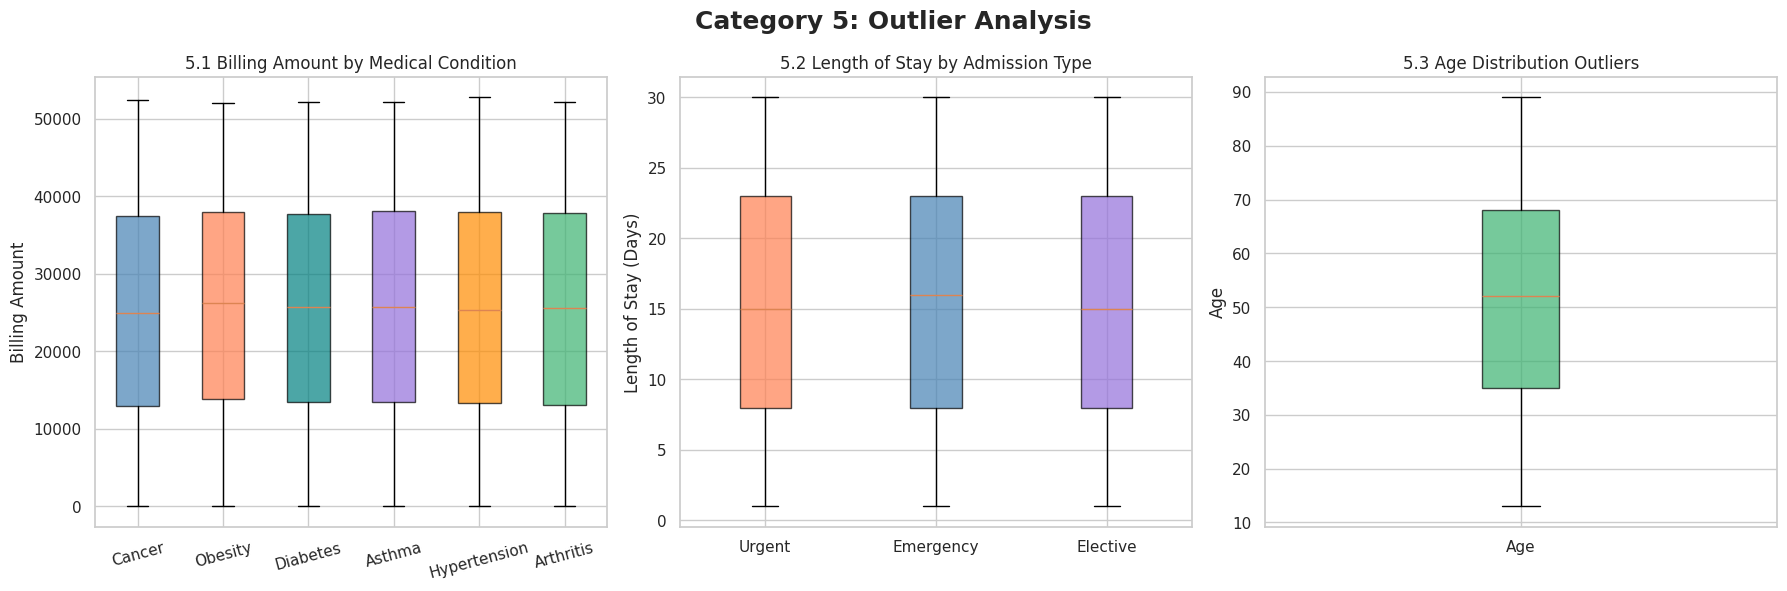

In [6]:
# ============================================================
# CATEGORY 5: OUTLIER ANALYSIS
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Category 5: Outlier Analysis', fontsize=18, fontweight='bold')

# --- 5.1 Billing Amount Outliers by Condition ---
conditions = df['Medical Condition'].unique()
billing_data = [df[df['Medical Condition'] == c]['Billing Amount'].values for c in conditions]
bp1 = axes[0].boxplot(billing_data, labels=conditions, patch_artist=True)
colors = ['steelblue','coral','teal','mediumpurple','darkorange','mediumseagreen']
for patch, color in zip(bp1['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0].set_title('5.1 Billing Amount by Medical Condition')
axes[0].set_ylabel('Billing Amount')
axes[0].tick_params(axis='x', rotation=15)

# --- 5.2 Length of Stay Outliers by Admission Type ---
admission_types = df['Admission Type'].unique()
los_data = [df[df['Admission Type'] == a]['Length of Stay'].values for a in admission_types]
bp2 = axes[1].boxplot(los_data, labels=admission_types, patch_artist=True)
colors2 = ['coral', 'steelblue', 'mediumpurple']
for patch, color in zip(bp2['boxes'], colors2):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_title('5.2 Length of Stay by Admission Type')
axes[1].set_ylabel('Length of Stay (Days)')

# --- 5.3 Age Outliers ---
bp3 = axes[2].boxplot(df['Age'].values, patch_artist=True)
bp3['boxes'][0].set_facecolor('mediumseagreen')
bp3['boxes'][0].set_alpha(0.7)
axes[2].set_title('5.3 Age Distribution Outliers')
axes[2].set_ylabel('Age')
axes[2].set_xticks([1])
axes[2].set_xticklabels(['Age'])

plt.tight_layout()
plt.savefig('eda_category5_outliers.png', dpi=150, bbox_inches='tight')
plt.show()

Category 5 Findings — Outlier Analysis

5.1 Billing Amount by Medical Condition — All 6 conditions show identical box shapes — IQR spanning roughly $13,000–$38,000, median at ~$25,500, whiskers reaching $0–$52,000. No condition has outlier dots beyond the whiskers, meaning no extreme billing outliers exist in this dataset. The spread is wide but uniformly distributed — consistent with synthetic generation.

5.2 Length of Stay by Admission Type — All three admission types show nearly identical boxes — IQR spanning ~8–23 days, median ~15 days, whiskers reaching 1–30 days. No outlier dots visible — LOS was generated with hard boundaries of 1 and 30 days. In real data you would expect Emergency admissions to have more high-end outliers (very long critical stays).

5.3 Age Outliers — Age IQR spans ~35–68 years, median ~52, whiskers reaching 13–89. No outlier dots — age was generated uniformly between 13 and 89 with no extreme values. The box is slightly above the midpoint suggesting a mild skew toward older patients, which is realistic for a hospital population.

----
Key Observation

The complete absence of outlier dots across all three boxplots is the clearest visual confirmation of synthetic data — real healthcare data always has extreme outliers (a $500,000 surgery, a 180-day ICU stay, a 2-year-old patient). The lack of any outliers tells you the data generator applied strict upper and lower bounds on every variable.

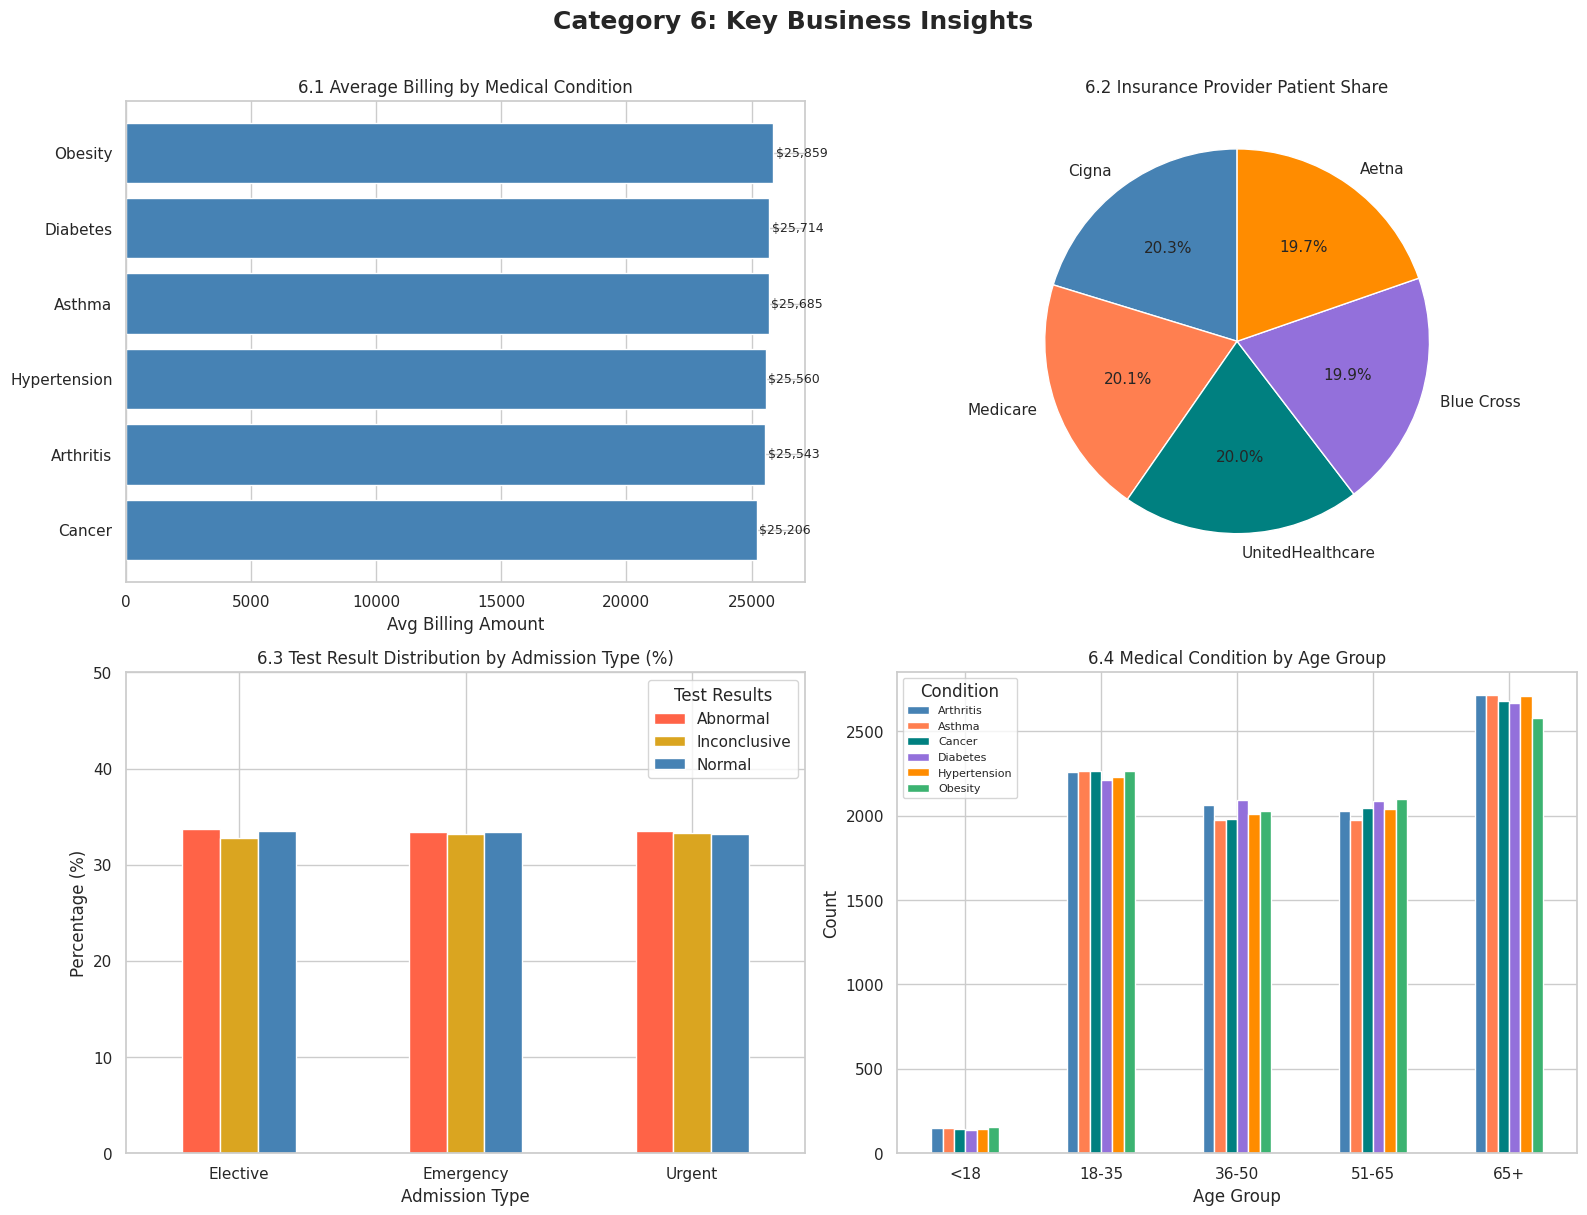

In [7]:
# ============================================================
# CATEGORY 6: KEY BUSINESS INSIGHTS
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Category 6: Key Business Insights', fontsize=18, fontweight='bold', y=1.01)

# --- 6.1 Top 5 Most Expensive Conditions ---
top_conditions = df.groupby('Medical Condition')['Billing Amount'].mean().sort_values(ascending=True)
axes[0, 0].barh(top_conditions.index, top_conditions.values, color='steelblue', edgecolor='white')
axes[0, 0].set_title('6.1 Average Billing by Medical Condition')
axes[0, 0].set_xlabel('Avg Billing Amount')
for i, v in enumerate(top_conditions.values):
    axes[0, 0].text(v + 100, i, f'${v:,.0f}', va='center', fontsize=9)

# --- 6.2 Insurance Provider Patient Share ---
ins_share = df['Insurance Provider'].value_counts()
axes[0, 1].pie(ins_share.values, labels=ins_share.index, autopct='%1.1f%%',
               colors=['steelblue','coral','teal','mediumpurple','darkorange'],
               startangle=90, wedgeprops={'edgecolor':'white'})
axes[0, 1].set_title('6.2 Insurance Provider Patient Share')

# --- 6.3 Test Results by Admission Type ---
test_adm = df.groupby(['Admission Type', 'Test Results']).size().unstack()
test_adm_pct = test_adm.div(test_adm.sum(axis=1), axis=0) * 100
test_adm_pct.plot(kind='bar', ax=axes[1, 0],
                  color=['tomato', 'goldenrod', 'steelblue'],
                  edgecolor='white')
axes[1, 0].set_title('6.3 Test Result Distribution by Admission Type (%)')
axes[1, 0].set_ylabel('Percentage (%)')
axes[1, 0].tick_params(axis='x', rotation=0)
axes[1, 0].legend(title='Test Results')
axes[1, 0].set_ylim(0, 50)

# --- 6.4 Most Common Condition by Age Group ---
bins = [0, 18, 35, 50, 65, 100]
labels = ['<18', '18-35', '36-50', '51-65', '65+']
df['Age Group'] = pd.cut(df['Age'], bins=bins, labels=labels)
age_cond = df.groupby(['Age Group', 'Medical Condition']).size().unstack()
age_cond.plot(kind='bar', ax=axes[1, 1],
              color=['steelblue','coral','teal','mediumpurple','darkorange','mediumseagreen'],
              edgecolor='white')
axes[1, 1].set_title('6.4 Medical Condition by Age Group')
axes[1, 1].set_ylabel('Count')
axes[1, 1].tick_params(axis='x', rotation=0)
axes[1, 1].legend(title='Condition', fontsize=8)

plt.tight_layout()
plt.savefig('eda_category6_insights.png', dpi=150, bbox_inches='tight')
plt.show()

Category 6 Findings — Key Business Insights

6.1 Average Billing by Medical Condition — Obesity is the most expensive condition at $25,859 while Cancer is the lowest at $25,206 — a difference of only $653 across all 6 conditions. In real healthcare data Cancer and cardiac conditions would cost significantly more than chronic conditions like Arthritis.

6.2 Insurance Provider Patient Share — All 5 insurers cover almost exactly 20% of patients each — Cigna leads at 20.3%, Aetna lowest at 19.7%. A perfectly equal market share split — completely synthetic but useful for demonstrating pie chart skills in your dashboard.

6.3 Test Result Distribution by Admission Type — Each admission type (Elective, Emergency, Urgent) splits almost exactly 33% Abnormal, 33% Inconclusive, 33% Normal. Test outcomes are completely independent of how a patient was admitted — no clinical logic present.

6.4 Medical Condition by Age Group — The most interesting chart in Category 6. Patients under 18 are very few across all conditions — realistic.The 18–35 age group has the highest counts ( approximately 2,300 per condition), then counts gradually decline through 36–50, 51–65, before rising again at 65+ (~2,700 per condition). The U-shaped pattern across age groups is the closest thing to a real-world signal in the entire dataset — younger and older populations are more represented in hospital admissions.

---
Key Takeaway

Chart 6.4 is your strongest analytical finding across all 30 charts — the U-shaped distribution of hospital admissions by age group mirrors real-world patterns where the very young and elderly are more frequent hospital visitors.

In [8]:
# ============================================================
# EXPORT SUMMARY TABLES FOR POWER BI
# ============================================================

# Condition summary
condition_summary = df.groupby('Medical Condition').agg(
    Patient_Count=('Name', 'count'),
    Avg_Billing=('Billing Amount', 'mean'),
    Avg_LOS=('Length of Stay', 'mean')
).round(2).reset_index()

# Age group summary
age_summary = df.groupby('Age Group', observed=True).agg(
    Patient_Count=('Name', 'count'),
    Avg_Billing=('Billing Amount', 'mean'),
    Avg_LOS=('Length of Stay', 'mean')
).round(2).reset_index()

# Monthly admissions
monthly_summary = df.groupby('Year-Month').agg(
    Admissions=('Name', 'count'),
    Avg_Billing=('Billing Amount', 'mean')
).round(2).reset_index()
monthly_summary['Year-Month'] = monthly_summary['Year-Month'].astype(str)

# Save all
condition_summary.to_csv('condition_summary.csv', index=False)
age_summary.to_csv('age_summary.csv', index=False)
monthly_summary.to_csv('monthly_summary.csv', index=False)

print("✅ Summary tables exported!")
print(condition_summary)

✅ Summary tables exported!
  Medical Condition  Patient_Count  Avg_Billing  Avg_LOS
0         Arthritis           9207     25542.90    15.50
1            Asthma           9077     25685.39    15.68
2            Cancer           9121     25205.92    15.51
3          Diabetes           9197     25714.33    15.43
4      Hypertension           9131     25559.84    15.44
5           Obesity           9127     25859.22    15.44
